# Real-world task II: spoken-digit recognition (protocol of nonMarkovianReservoirComputer)

## Statement of the problem
Automatic spoken-digit recognition on the Free Spoken Digit Dataset with the protocol of the non-Markovian (atom-in-front-of-a-mirror) reservoir study, so that the squeezed cavity is trained on exactly the same task: 5 speakers × 10 digits × 10 recordings; mel spectrogram (`librosa`, `n_fft=len(audio)`, `power_to_db(ref=mean)`) split into a $6\times6$ block grid; block **means** and block **stds** are two input channels of 36 values per utterance, each min–max normalized to $[0,1]$; utterances fed consecutively, no separators; features $=(P,Q)$ at the end of each of the 36 input steps (144 per utterance); 5 washout utterances; ten one-vs-all ridge classifiers ($\delta=10^{-10}$, bias); winner-takes-all; word error rate under 5-fold cross-validation (`KFold(5, shuffle=True, random_state=99)`).

**Selection rule.** $\delta=10^{-10}$ fits the 395 training utterances exactly (training WER 0), so the training loss is a weak surrogate; the operating point is selected by the training loss on fold 1 only, and the 5-fold WER is reported at that point — the test error is never used for selection.

Script `run_asr.py` (features cached in `data/asr_features.npz`; one fold evaluation ≈ 14 s, full pipeline ≈ 40 min). Requires `librosa`, `scikit-learn` and the FSDD recordings in `$FSDD_DIR` (default `~/fsdd`).

Two earlier protocols (`run_digits*.py`: two speakers, 8-channel filterbank time-multiplexed, 192-feature frame-wise readout; then a WTA-aligned cross-validated loss) gave a landscape with a few percent of relief and no resolvable accuracy change at a 60-utterance test set; they are superseded by the protocol above and are kept in the code for the record.

In [1]:
import os, sys, subprocess, numpy as np
CODE = os.path.abspath(os.path.join(os.getcwd(), '..', 'code')); sys.path.insert(0, CODE); os.chdir(CODE); os.environ['OMP_NUM_THREADS'] = '1'
import matplotlib; matplotlib.use('Agg'); import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from common import *
import make_figs
RUN = False   # set True to recompute the data for this notebook (see the "Compute" section for the cost)
def show(pdf, dpi=110):
    """Render a figure PDF from paper/figs inline."""
    base = '/tmp/' + os.path.basename(pdf)[:-4]; subprocess.run(['pdftoppm', '-r', str(dpi), '-png', '-singlefile', pdf, base], check=True); display(Image(filename=base + '.png'))
def ld(name):
    p = os.path.join(DATA, name); return np.load(p, allow_pickle=True) if os.path.exists(p) else None


In [2]:
if RUN: subprocess.run(['python3', 'run_asr.py', 'all'])
asr = ld('asr.npz')
print('5-fold WER: frontend ridge %s -> %.1f%%; unsqueezed %s -> %.1f%%; squeezed (%.1f, %.1f, %.2f, phi_s=%s) %s -> %.1f%%' % (
    asr['frontend'].round(2), 100 * asr['frontend'].mean(), asr['unsq5'][:, 1].round(2), 100 * asr['unsq5'][:, 1].mean(), *asr['best'], 'pi' if float(asr['best_s']) < 0 else '0', asr['best5'][:, 1].round(2), 100 * asr['best5'][:, 1].mean()))
S = asr['scan']; print('fold-1 training loss: unsqueezed %.5f; best on de-amplifying grid %.5f; best on amplifying grid %.5f' % (S[0, 0, 0], asr['grid_p'][:, :, 0].min(), asr['grid_m'][:, :, 0].min()))
print('six-observable readout (432 features) overfits: WER %.0f%% / %.0f%%' % (100 * asr['unsq5_all'][:, 1].mean(), 100 * asr['best5_all'][:, 1].mean()))

5-fold WER: frontend ridge [0.06 0.08 0.12 0.15 0.14] -> 11.0%; unsqueezed [0.07 0.09 0.16 0.14 0.14] -> 12.0%; squeezed (0.4, 0.0, 0.00, phi_s=pi) [0.08 0.05 0.07 0.11 0.09] -> 8.0%
fold-1 training loss: unsqueezed 0.00807; best on de-amplifying grid 0.00739; best on amplifying grid 0.00732
six-observable readout (432 features) overfits: WER 43% / 50%


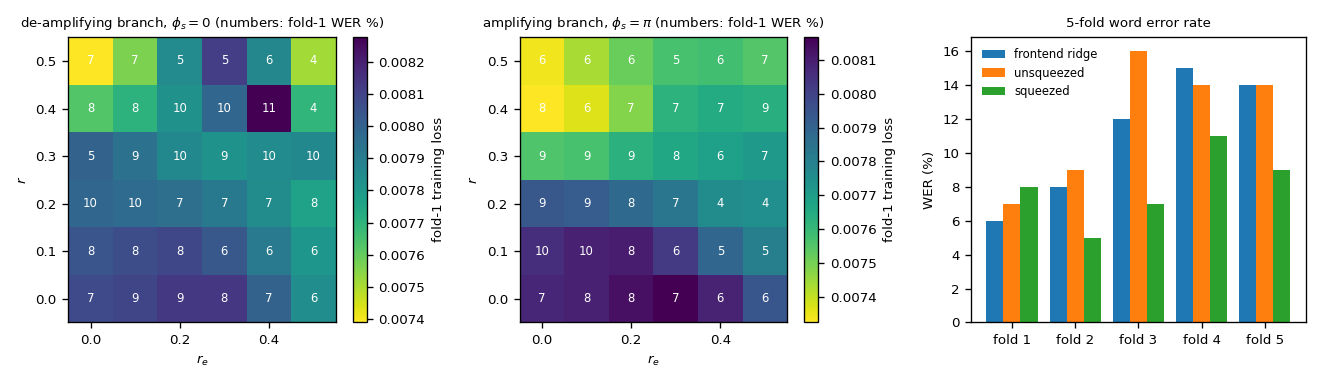

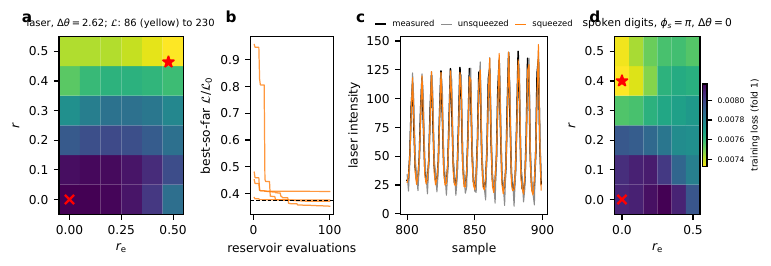

In [3]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 3, figsize=(11, 3.2)); g = asr['grid']
for ax, tag, tt in zip(axs[:2], ('p', 'm'), ('de-amplifying branch, $\\phi_s=0$', 'amplifying branch, $\\phi_s=\\pi$')):
    G = asr[f'grid_{tag}']; im = ax.pcolormesh(g, g, G[:, :, 0], cmap='viridis_r', shading='nearest'); fig.colorbar(im, ax=ax, label='fold-1 training loss')
    for i in range(6):
        for j in range(6): ax.text(g[j], g[i], '%.0f' % (100 * G[i, j, 1]), ha='center', va='center', fontsize=7, color='w')
    ax.set_xlabel('$r_e$'); ax.set_ylabel('$r$'); ax.set_title(tt + ' (numbers: fold-1 WER %)')
ax = axs[2]; x = np.arange(5); w = 0.27
ax.bar(x - w, 100 * asr['frontend'], w, label='frontend ridge'); ax.bar(x, 100 * asr['unsq5'][:, 1], w, label='unsqueezed'); ax.bar(x + w, 100 * asr['best5'][:, 1], w, label='squeezed')
ax.set_xticks(x); ax.set_xticklabels(['fold %d' % (i + 1) for i in x]); ax.set_ylabel('WER (%)'); ax.legend(frameon=False); ax.set_title('5-fold word error rate')
plt.tight_layout(); plt.savefig('/tmp/asr_nb.png', dpi=120); plt.close(fig); display(Image('/tmp/asr_nb.png'))
make_figs.fig_real(); show('paper/figs/fig_real.pdf')

**Result.** The fabricated device does no better than its spectrogram frontend (12.0% vs 11.0% WER). The amplifying parametric branch raises the input to $\epsilon e^{r}$ and the emitter excitation from 0.19 to 2.0 photons; at $(r,r_e,\Delta\theta)=(0.4,0,0)$, $\phi_s=\pi$, the 5-fold WER is 8.0% — a 33% relative reduction, below the frontend. Same mechanism as Lorenz; opposite branch to the laser.